In [1]:
# Create Data Folder

import os, shutil

os.makedirs("Car_price_regression_autoML", exist_ok=True)
print("Folder created")

Folder created


In [2]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# Data Ingestion

# Specify the target directory within the writable file system
target_dir = "Car_price_regression_autoML"

# Download latest version directly to the target directory
!kaggle datasets download -d therohithanand/used-car-price-prediction

shutil.move("used-car-price-prediction.zip", target_dir)
shutil.unpack_archive(os.path.join(target_dir, "used-car-price-prediction.zip"), target_dir)

print("Path to dataset files:", target_dir)

Dataset URL: https://www.kaggle.com/datasets/therohithanand/used-car-price-prediction
License(s): CC-BY-SA-4.0
  0% 0.00/141k [00:00<?, ?B/s]
100% 141k/141k [00:00<00:00, 316MB/s]
Path to dataset files: Car_price_regression_autoML


In [5]:
!pip install -f http://h2o-release.s3.amazonaws.com/h2o/latest_stable_Py.html h2o --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 MB 5.0 MB/s eta 0:00:00


In [6]:
!pip install comet_ml --q
!pip install pyngrok --q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.1/727.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 43.1 MB/s eta 0:00:00


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Read dataset

df = pd.read_csv("/content/Car_price_regression_autoML/used_car_price_dataset_extended.csv")
df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


In [9]:
# Fill the null values in service_history for better visualization

values = {"service_history":"None"}

df.fillna(value = values, inplace=True)

In [10]:
# Car Age

from datetime import datetime

current_year = datetime.now().year

df["car_age"] = current_year - df["make_year"].astype(int)

In [11]:
# Has_accident

df["has_accident"] = df["accidents_reported"].apply(lambda x: 1 if x > 0 else 0)

In [12]:
# Ordinal encoding of the column service_history

df.loc[df["service_history"] == "None","service_history"] = 0
df.loc[df["service_history"] == "Partial","service_history"] = 1
df.loc[df["service_history"] == "Full","service_history"] = 2

In [13]:
# Using pd.get_dummies to encode remaining categorical features

cat_cols = ["fuel_type","brand","transmission","color","insurance_valid"]

enc_df = pd.get_dummies(df[cat_cols],drop_first=True)
df_final = pd.concat([df,enc_df],axis=1)
df_final.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,...,brand_Tesla,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,insurance_valid_Yes
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,0,...,False,False,False,True,False,False,False,False,True,False
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,0,...,False,False,False,True,False,False,False,False,False,True
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,2,...,False,False,False,False,False,False,False,False,False,True
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,2,...,False,False,False,True,True,False,False,False,False,True
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,2,...,False,False,False,False,False,False,True,False,False,True


In [14]:
# Drop unnecessary columns

df_final.drop(columns=["make_year","fuel_type","brand","transmission","color","insurance_valid"],inplace=True)
df_final.head()

,mileage_kmpl,engine_cc,owner_count,price_usd,service_history,accidents_reported,car_age,has_accident,fuel_type_Electric,fuel_type_Petrol,...,brand_Tesla,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,insurance_valid_Yes
0,8.17,4000,4,8587.64,0,0,24,0,False,True,...,False,False,False,True,False,False,False,False,True,False
1,17.59,1500,4,5943.50,0,0,11,0,False,True,...,False,False,False,True,False,False,False,False,False,True
2,18.09,2500,5,9273.58,2,1,2,1,False,False,...,False,False,False,False,False,False,False,False,False,True
3,11.28,800,1,6836.24,2,0,16,0,False,True,...,False,False,False,True,True,False,False,False,False,True
4,12.23,1000,2,4625.79,2,0,20,0,False,True,...,False,False,False,False,False,False,True,False,False,True


In [16]:
import os
os.environ['COMET_API_KEY'] = 'O7avS6qNp36pdPrT8NMZFmLO7'

In [18]:
import comet_ml
comet_ml.login()

In [19]:
exp = comet_ml.start(project_name="Regression_car_price_h20ml")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/deepaktripathy1/regression-car-price-h20ml/c1d81d3a56a642d98303a0fdf9b83265



In [20]:
import h2o
from h2o.automl import H2OAutoML
from sklearn.model_selection import train_test_split

# Start H20 cluster
h2o.init()

# Train-test split
train, test = train_test_split(df_final, test_size=0.2, random_state=42)

# Convert to H20Frame
train_h2o = h2o.H2OFrame(train)
test_h2o = h2o.H2OFrame(test)

# Set response variable and predictors
response = "price_usd"
predictors = [col for col in df_final.columns if col != response]

# Run automl
automl = H2OAutoML(max_models=10, seed=42, verbosity = "info")
automl.train(x=predictors, y=response, training_frame=train_h2o)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.27" 2025-04-15; OpenJDK Runtime Environment (build 11.0.27+6-post-Ubuntu-0ubuntu122.04); OpenJDK 64-Bit Server VM (build 11.0.27+6-post-Ubuntu-0ubuntu122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.11/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpyi7k5d98
  JVM stdout: /tmp/tmpyi7k5d98/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpyi7k5d98/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,07 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,3 months and 6 days
H2O_cluster_name:,H2O_from_python_unknownUser_ht7mqc
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.170 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
11:51:48.924: Project: AutoML_1_20250704_115148
11:51:48.927: 5-fold cross-validation will be used.
11:51:48.928: Setting stopping tolerance adaptively based on the training frame: 0.011180339887498949
11:51:48.928: Build control seed: 42
11:51:48.930: training frame: Frame key: AutoML_1_20250704_115148_training_Key_Frame__upload_901d5da8ad51f180fb04649a2a2940b4.hex    cols: 26    rows: 8000  chunks: 1    size: 125042  checksum: -7273691401451663966
11:51:48.930: validation frame: NULL
11:51:48.931: leaderboard frame: NULL
11:51:48.931: blending frame: NULL
11:51:48.931: response column: price_usd
11:51:48.932: fold column: null
11:51:48.932: weights column: null
11:51:48.980: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w)

key,value
Stacking strategy,cross_validation
Number of base models (used / total),6/10
# GBM base models (used / total),4/4
# XGBoost base models (used / total),1/3
# DRF base models (used / total),1/2
# GLM base models (used / total),0/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


# Residual Analysis

> Residual Analysis plots the fitted values vs residuals on a test dataset. Ideally, residuals should be randomly distributed. Patterns in this plot can indicate potential problems with the model selection, e.g., using simpler model than necessary, not accounting for heteroscedasticity, autocorrelation, etc. Note that if you see "striped" lines of residuals, that is an artifact of having an integer valued (vs a real valued) response variable.

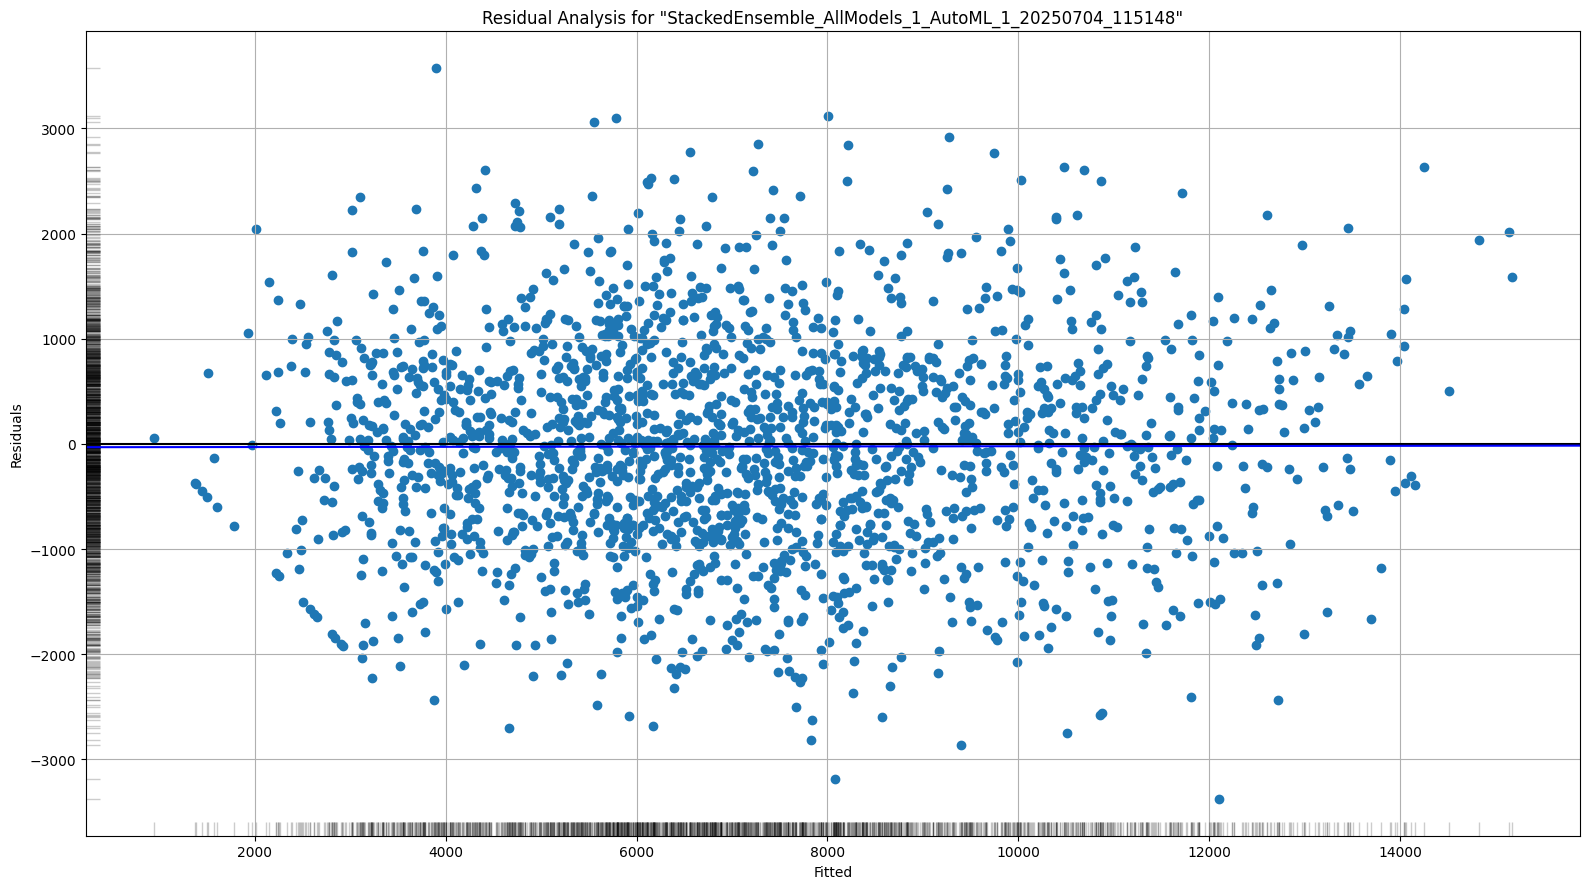

# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

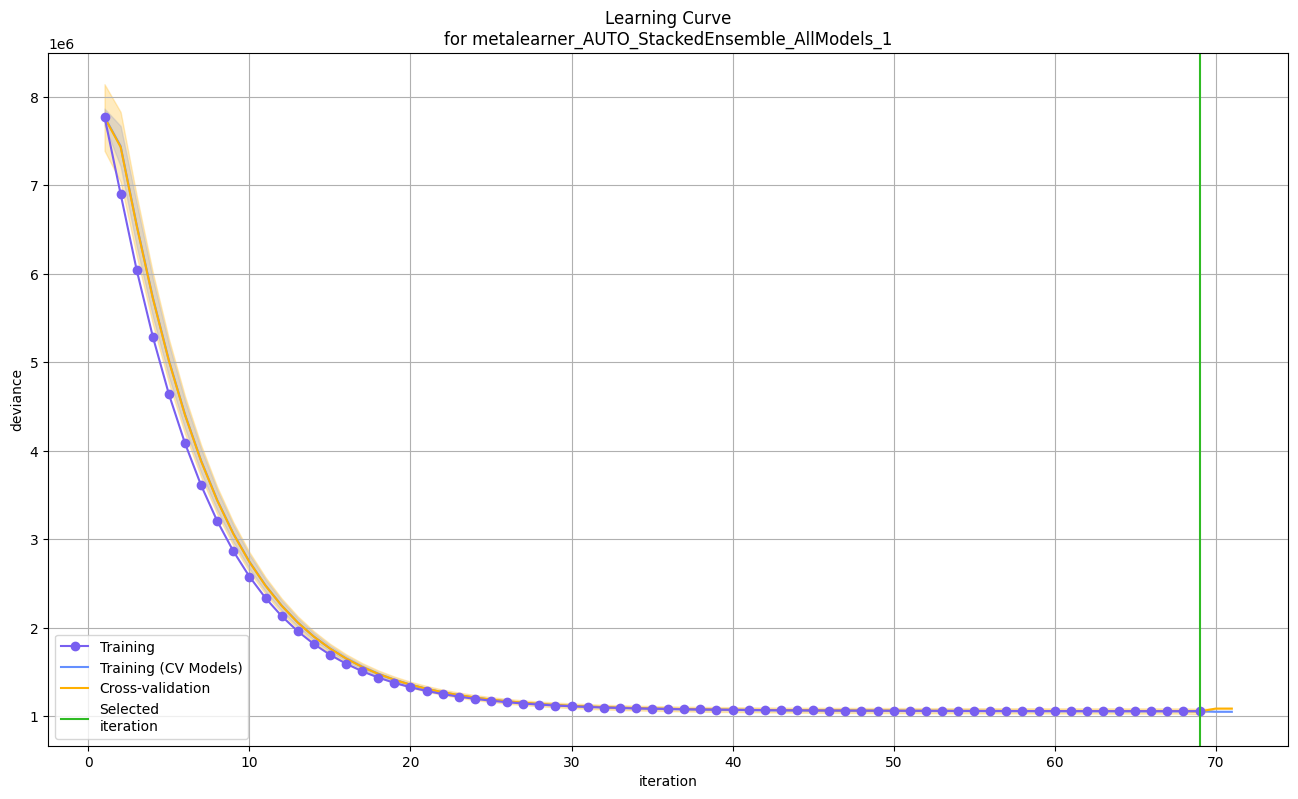

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

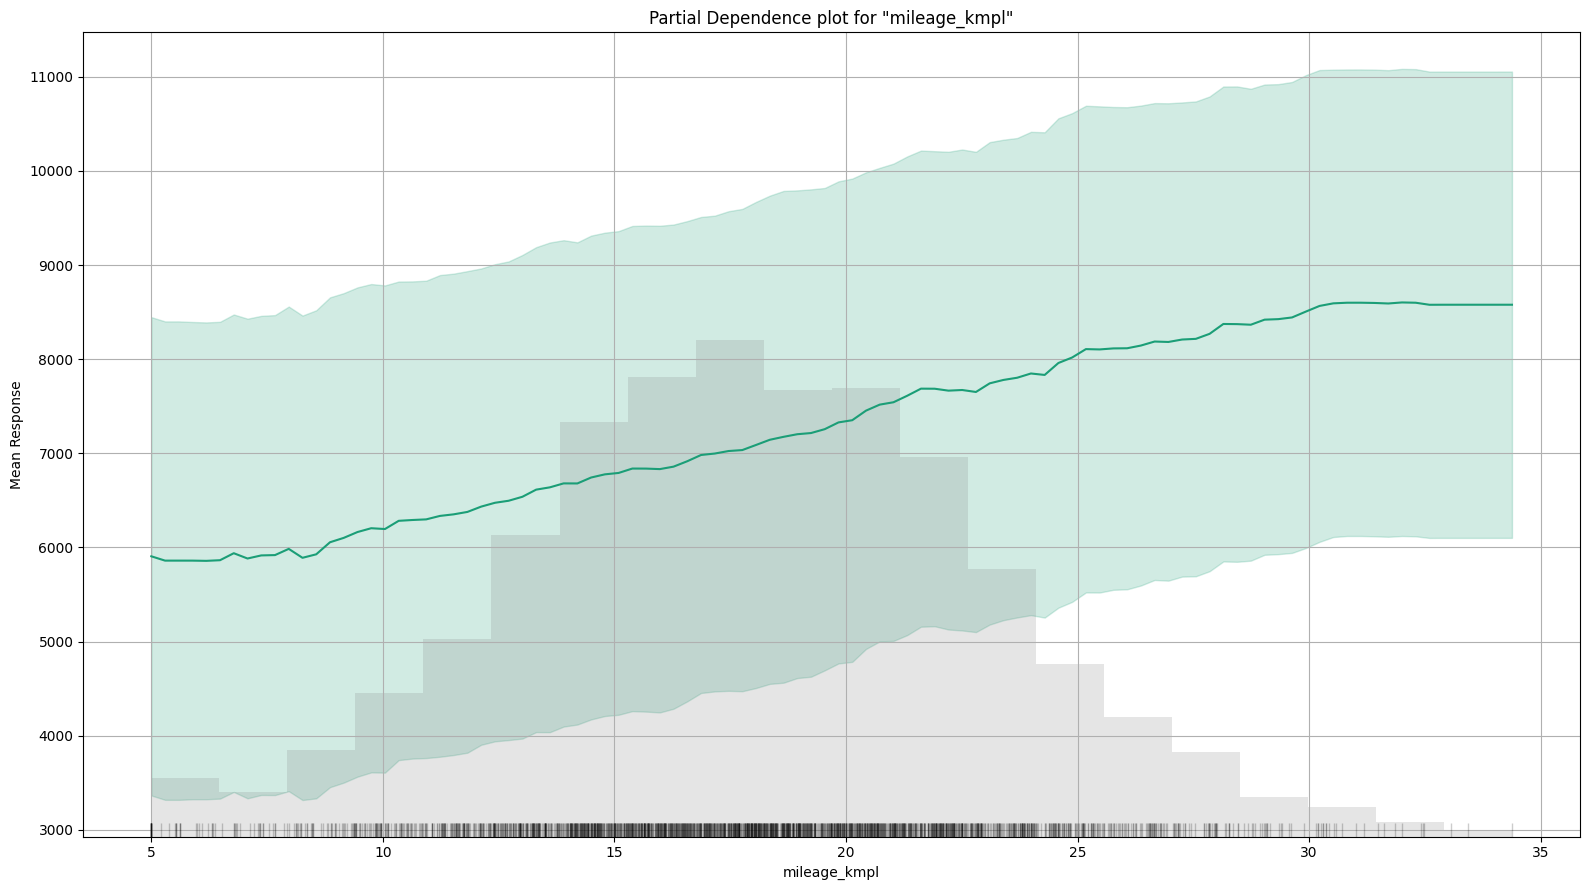

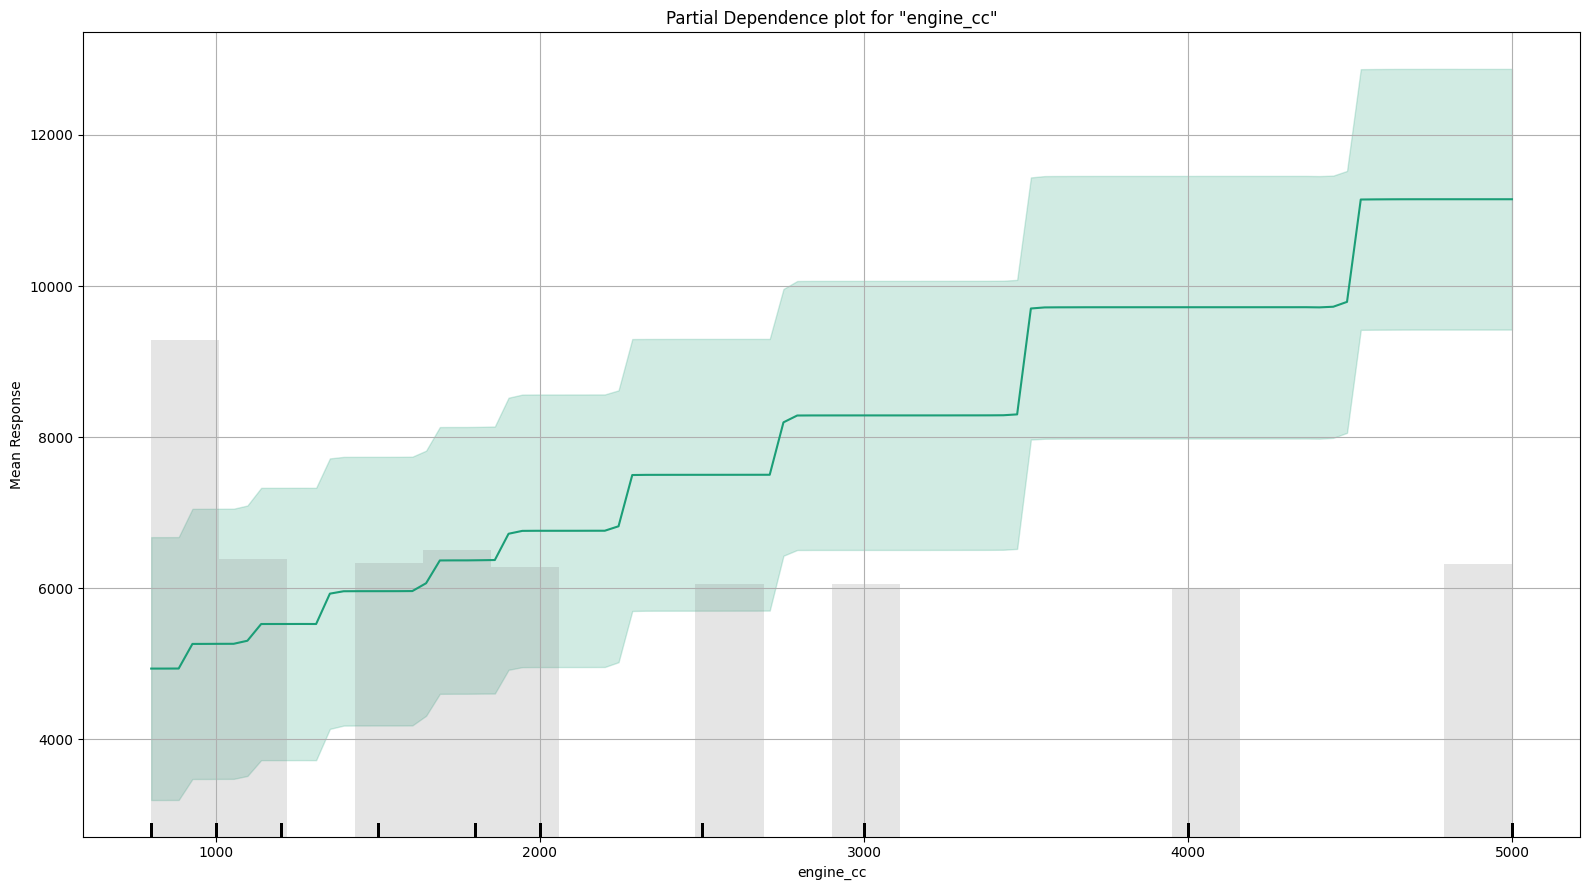

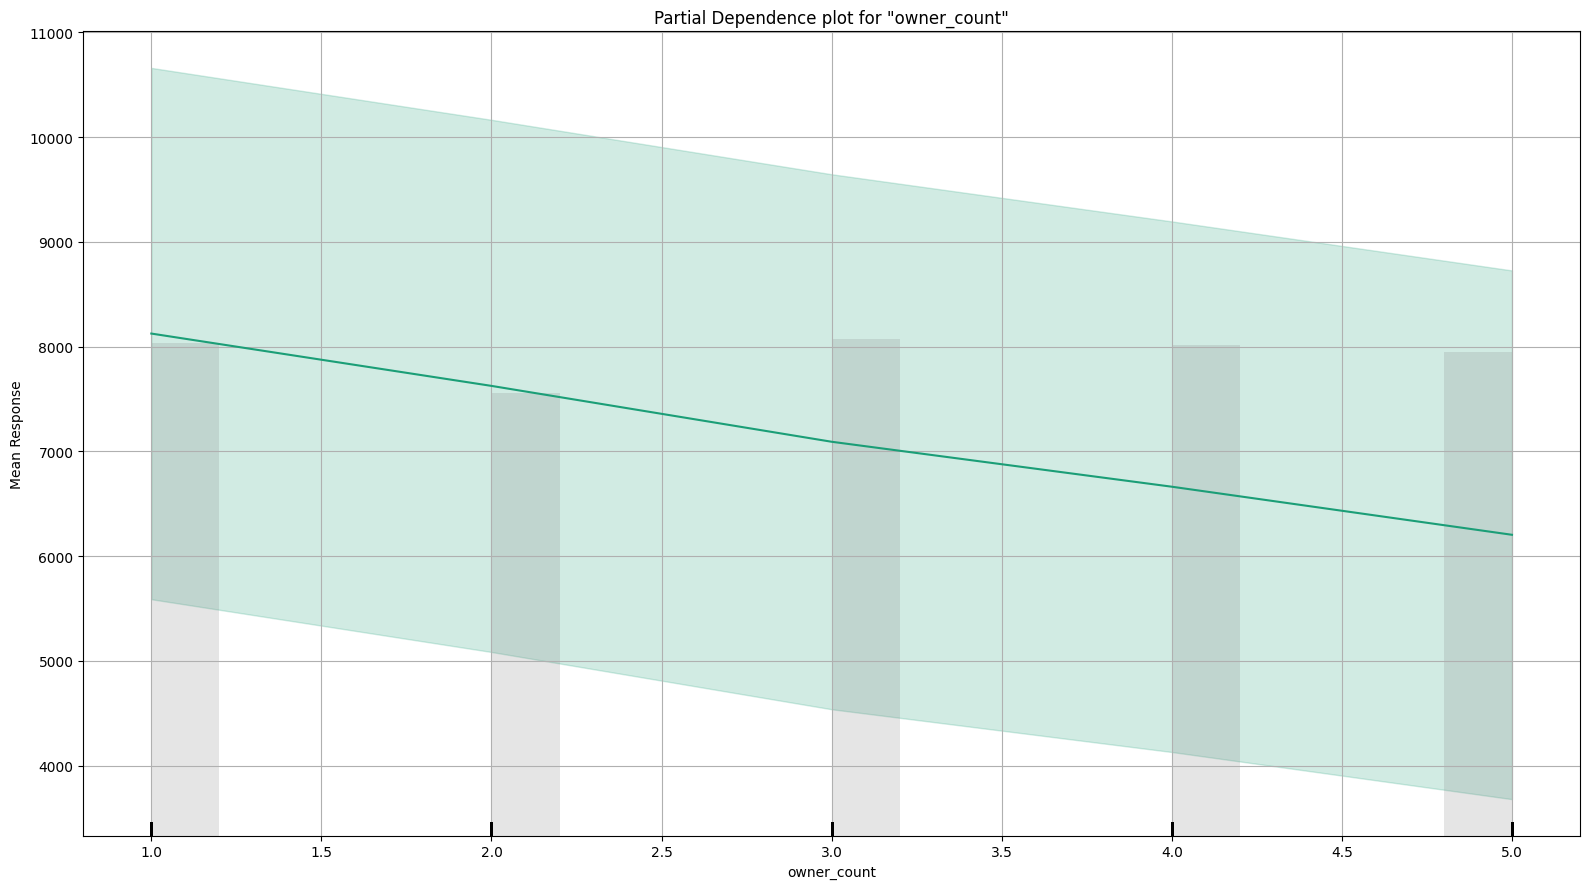

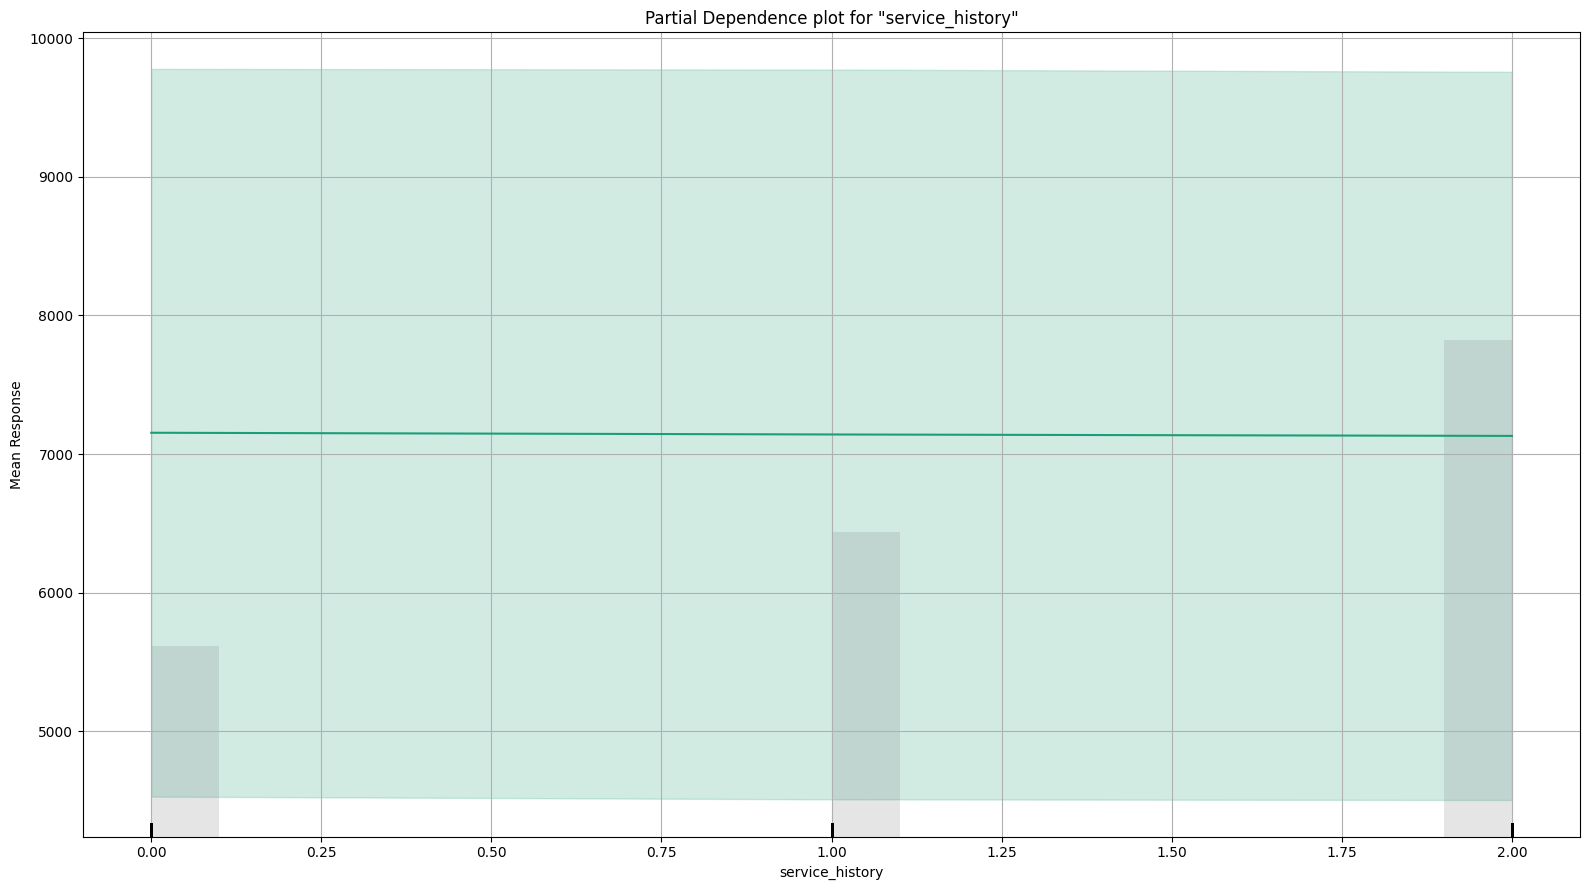

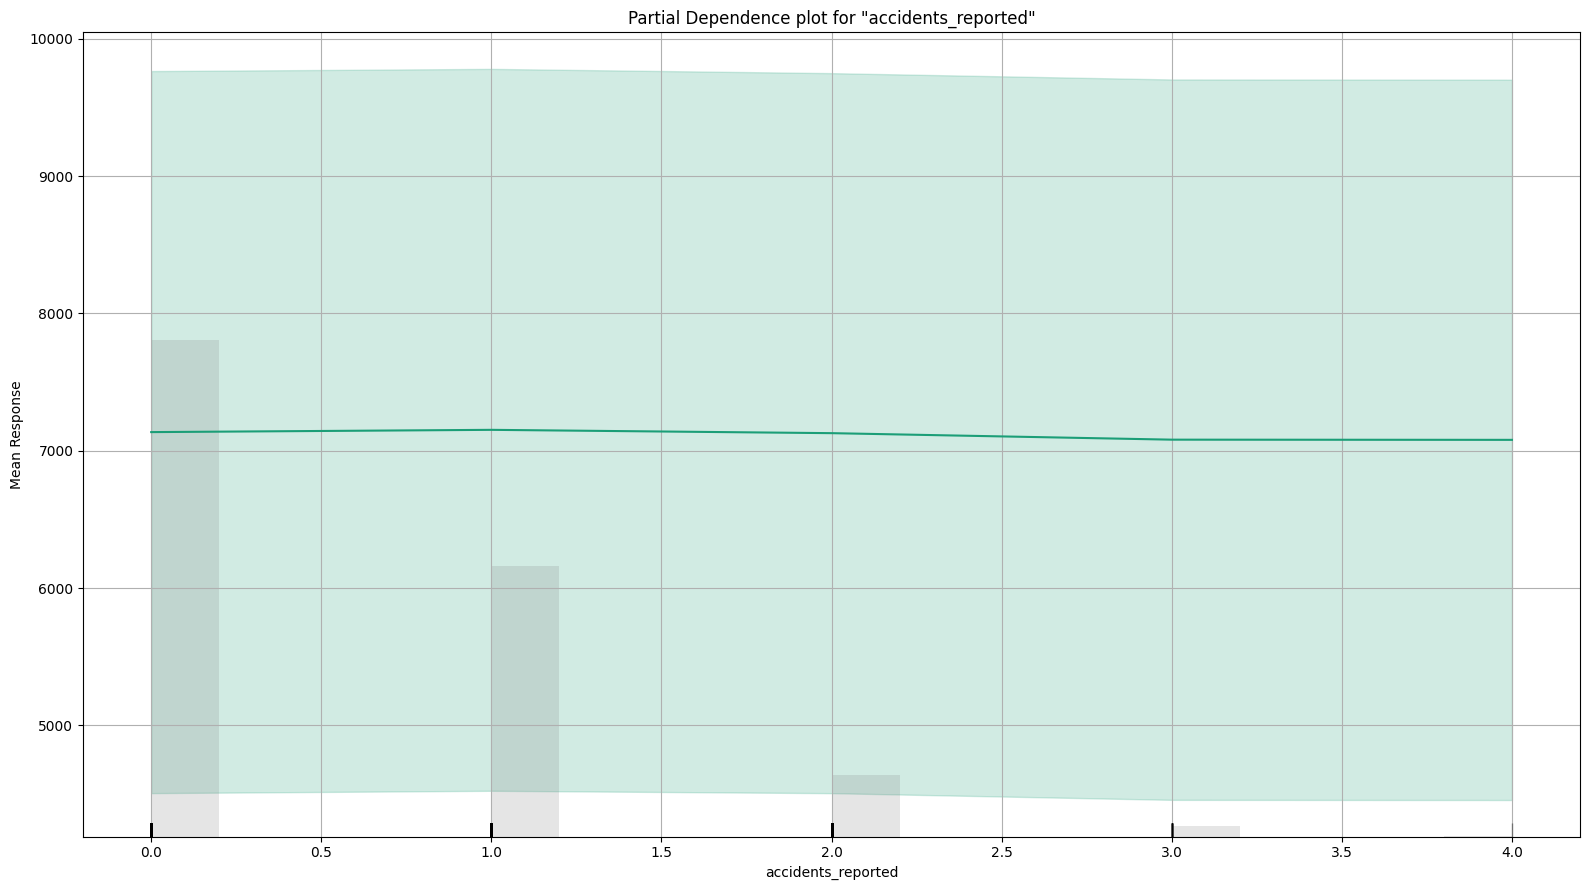

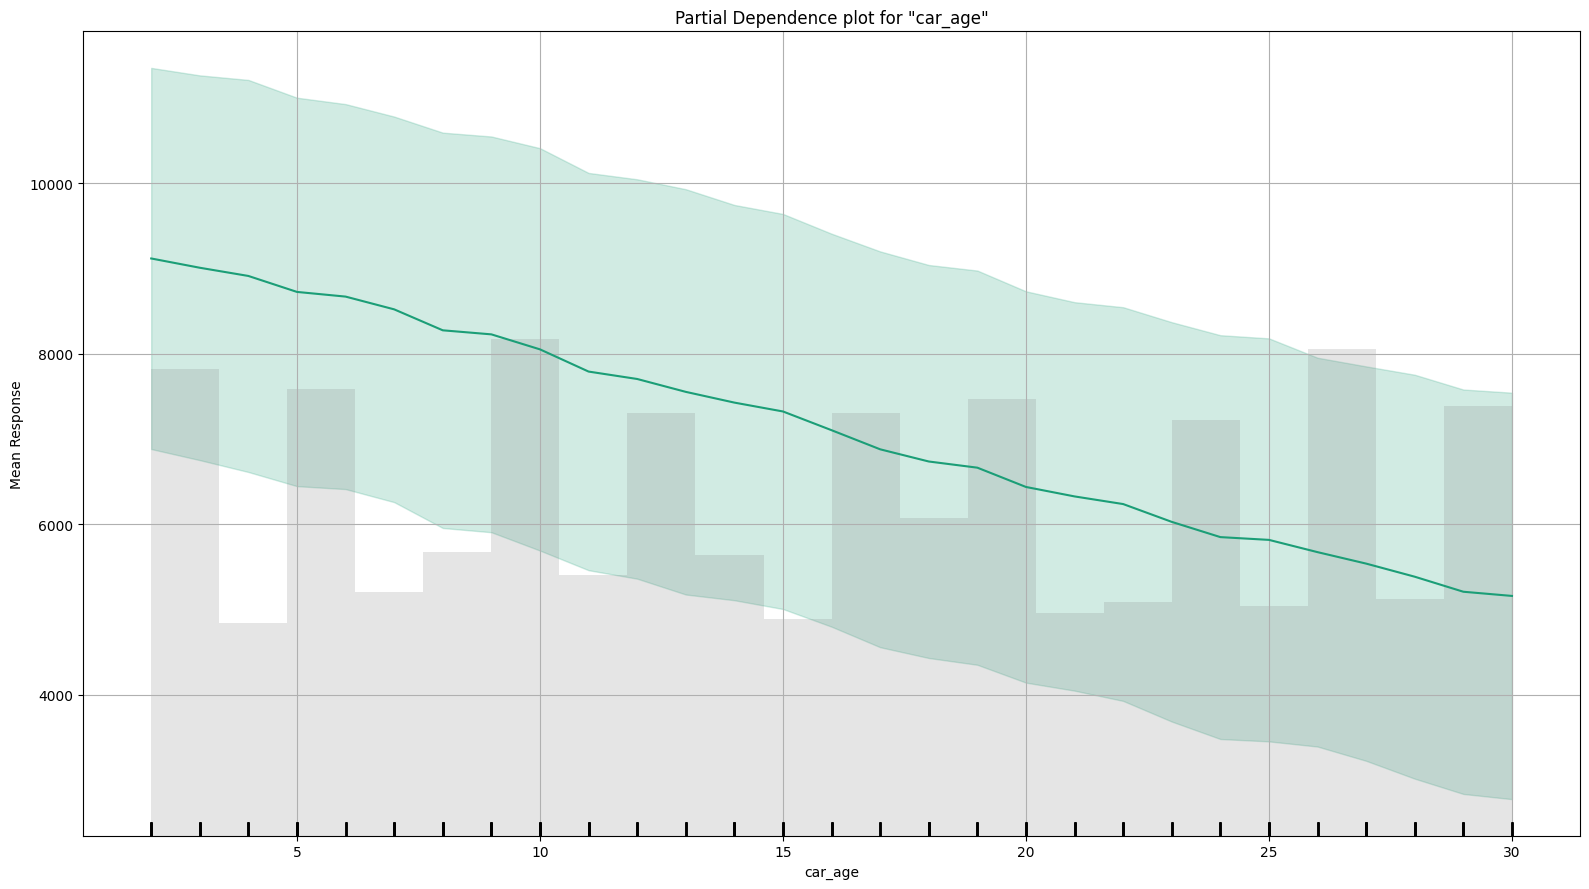

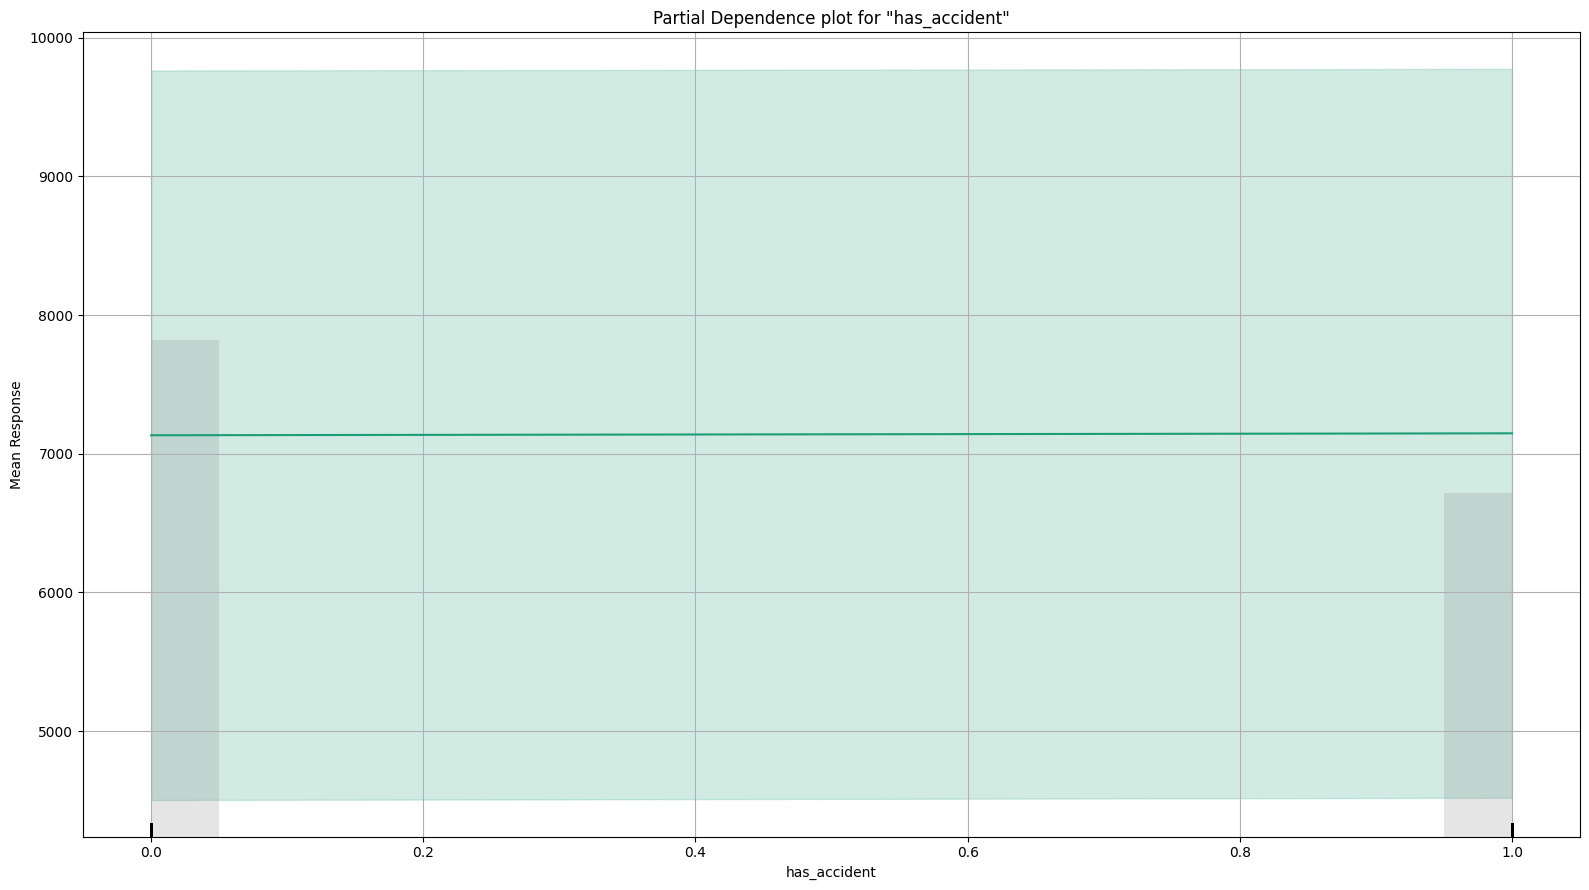

H2OResponseError: Server error java.lang.IllegalArgumentException:
  Error: Incorrect number of arguments; 'cols_py' expects 2 but was passed 3
  Request: POST /99/Rapids
    data: {'ast': "(tmp= py_26_sid_ad8e (levels (tmp= py_25_sid_ad8e (as.factor (cols_py py_24_sid_ad8e np.str_('fuel_type_Electric'))))))", 'session_id': '_sid_ad8e'}


In [22]:
from h2o.explanation import explain

# Model explanation on test data
explain(automl.leader, test_h2o)

PartialDependencePlot progress: |

/tmp/ipython-input-26-1393214187.py:8: H2ODeprecationWarning: ``data`` param of ``ModelBase.partial_plot`` is deprecated, please use ``frame`` instead.
  base_model.partial_plot(data=test_h2o, cols=["fuel_type_Electric"], plot=True)


████████████████████████████████████████████████| (done) 100%


[PartialDependence: Partial Dependence Plot of model GBM_1_AutoML_1_20250704_115148 on column 'fuel_type_Electric'.
fuel_type_electric    mean_response    stddev_response    std_error_mean_response
--------------------  ---------------  -----------------  -------------------------
False                 6880.54          2473.79            55.3157
True                  9800.85          2255.58            50.4363]

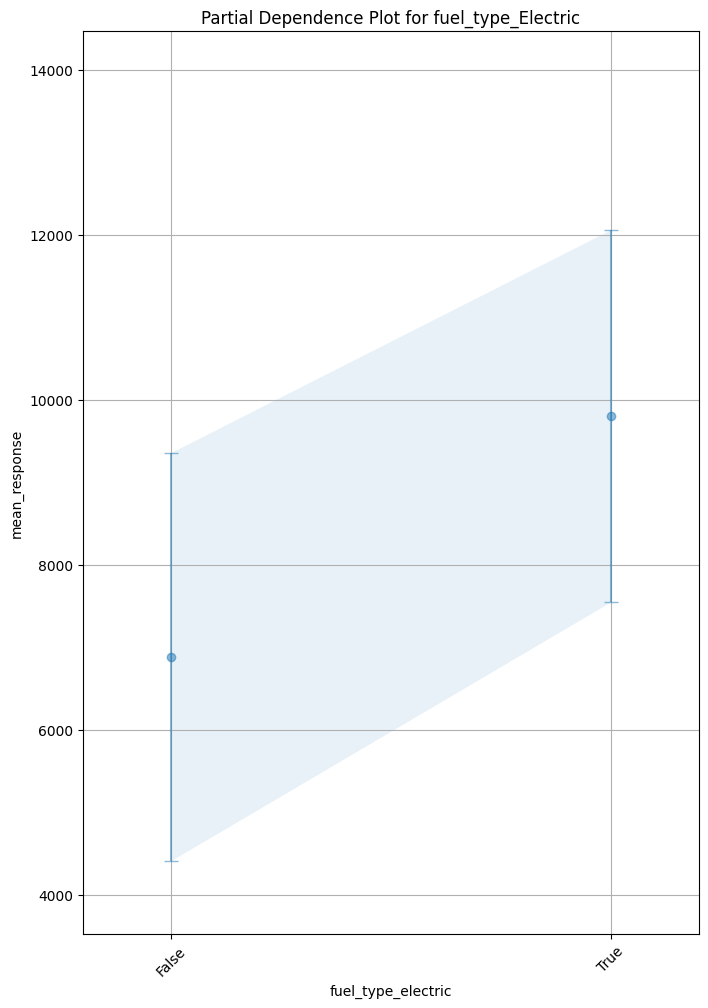

In [26]:
# Get base models of the ensemble
metalearner = h2o.get_model(automl.leader.metalearner()['name'])

# OR get first model in the ensemble stack
base_model = h2o.get_model(automl.leader.base_models[0])

# Use PDP from base model
base_model.partial_plot(data=test_h2o, cols=["fuel_type_Electric"], plot=True)

In [27]:
automl.get_leaderboard()

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
StackedEnsemble_AllModels_1_AutoML_1_20250704_115148,1028.82,1.05847e+06,818.614,0.190336,1.05847e+06
StackedEnsemble_BestOfFamily_1_AutoML_1_20250704_115148,1029.76,1.0604e+06,819.525,0.190254,1.0604e+06
GBM_1_AutoML_1_20250704_115148,1033.88,1.06892e+06,823.042,0.19084,1.06892e+06
GBM_2_AutoML_1_20250704_115148,1045.54,1.09316e+06,831.225,0.193827,1.09316e+06
GBM_3_AutoML_1_20250704_115148,1054.79,1.11258e+06,838.256,0.195877,1.11258e+06
XGBoost_3_AutoML_1_20250704_115148,1055.67,1.11445e+06,841.183,0.194425,1.11445e+06
GBM_4_AutoML_1_20250704_115148,1078.99,1.16422e+06,855.91,0.200978,1.16422e+06
DRF_1_AutoML_1_20250704_115148,1094.68,1.19832e+06,868.36,0.203495,1.19832e+06
XGBoost_1_AutoML_1_20250704_115148,1159.87,1.3453e+06,927.402,0.213364,1.3453e+06
XGBoost_2_AutoML_1_20250704_115148,1165.9,1.35933e+06,921.86,0.214875,1.35933e+06


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
COMET INFO: Artifact 'best_regression_model' version 1.0.0 created
COMET INFO: Scheduling the upload of 1 assets: 1 local assets for a size of 22.98 MB, and 0 remote assets (will be linked, not uploaded). This can 

LoggedArtifact(artifact_name='best_regression_model', artifact_type='model', workspace='deepaktripathy1', version=Version('1.0.0'), aliases=frozenset(), artifact_tags=frozenset(), version_tags=frozenset(), size=0, source_experiment_key='c1d81d3a56a642d98303a0fdf9b83265')

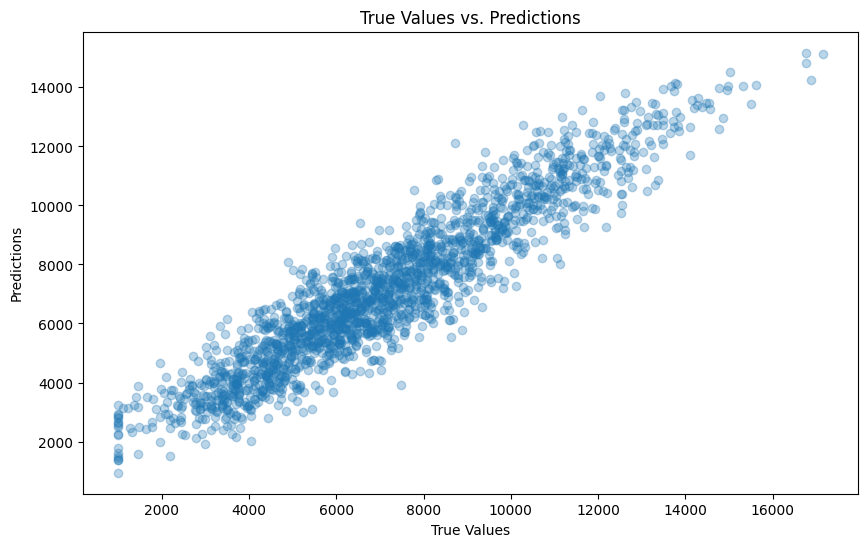

In [36]:
# Log parameters

parent_dir = "/content/Car_price_regression_autoML"
model_dir = "H20ML_best_model"
model_path = os.path.join(parent_dir, model_dir)

exp.log_parameters({
    "project" : "Regression_car_price_h20ml",
    "dataset" : "used_car_price_dataset_extended.csv",
    "target" : "price_usd",
    "features" : len(predictors),
    "model_count" : len(automl.leaderboard)
})

# Log leaderboard
lb_df = automl.leaderboard.as_data_frame()
exp.log_table("leaderboard.csv",lb_df)

# Log best metrics
leader = automl.leader
performance = leader.model_performance(test_h2o)

metrics = {
    "RMSE" : performance.rmse(),
    "MAE" : performance.mae(),
    "R2" : performance.r2(),
    "MSE" : performance.mse()
}
exp.log_metrics(metrics)

# Save and log the model

model_path = h2o.save_model(model=automl.leader, path=model_path, force=True)
exp.log_model("best_model", model_path)

# Predict and plot
predictions_df = leader.predict(test_h2o).as_data_frame()
predictions = predictions_df["predict"].values.flatten()
true_vals_df = test_h2o[response].as_data_frame()
true_vals = true_vals_df[response].values.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(true_vals, predictions, alpha=0.3)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True Values vs. Predictions")
plot_path = os.path.join(parent_dir, "true_vs_pred.png")
plt.savefig(plot_path)
exp.log_image(plot_path,name="true_vs_pred")

# Log custom artifact

from comet_ml import Artifact

artifact = Artifact(name="best_regression_model", artifact_type="model")
artifact.add("/content/Car_price_regression_autoML/H20ML_best_model/StackedEnsemble_AllModels_1_AutoML_1_20250704_115148")
exp.log_artifact(artifact)

/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"



Top 5 features for model : GBM_1_AutoML_1_20250704_115148:


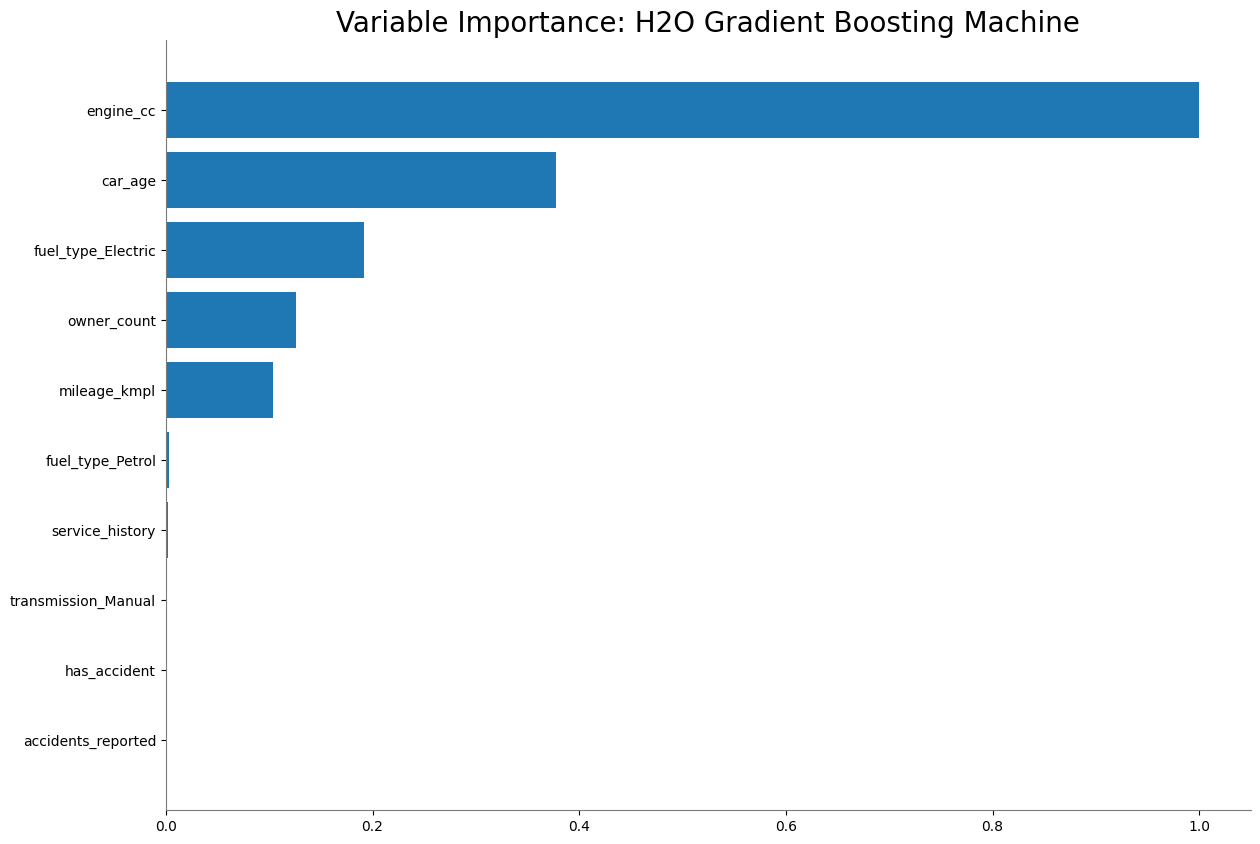


Top 5 features for model : GBM_2_AutoML_1_20250704_115148:


<Figure size 640x480 with 0 Axes>

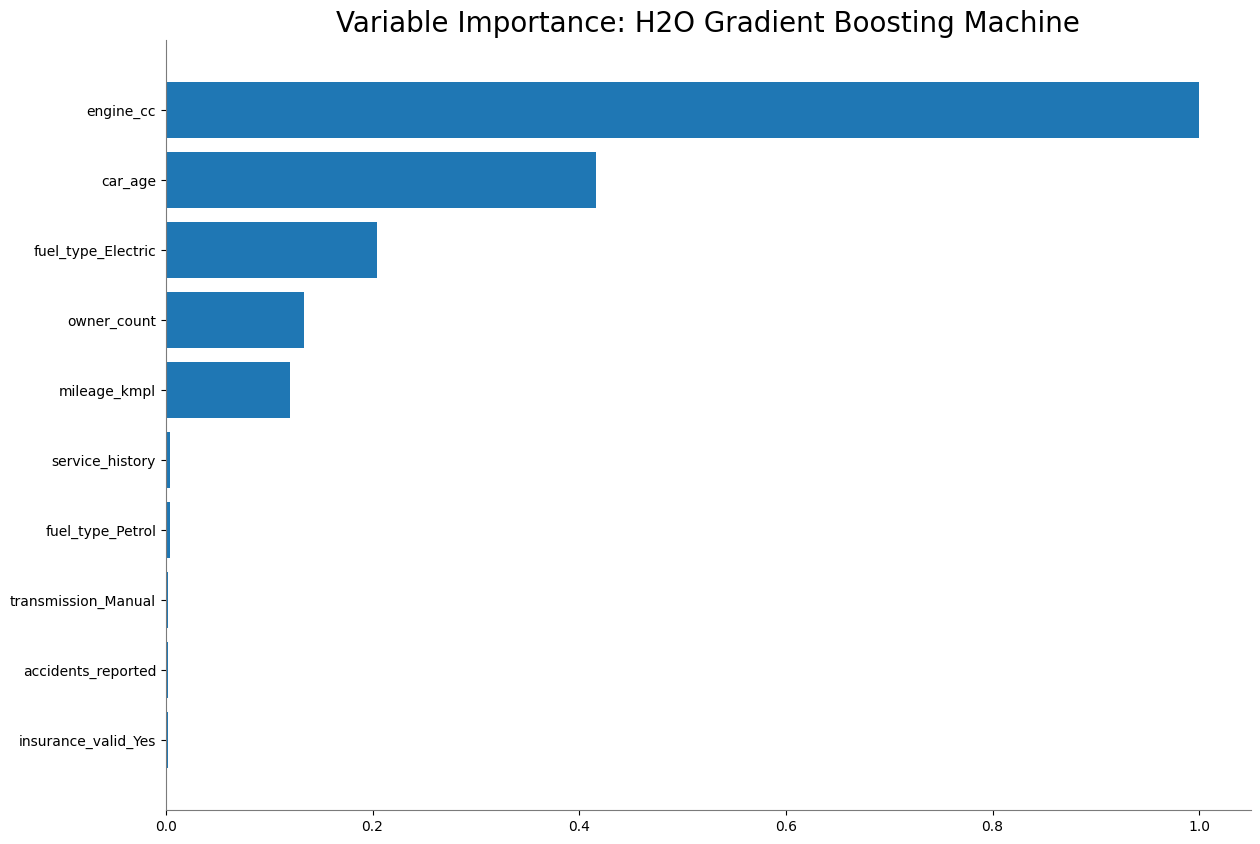


Top 5 features for model : GBM_3_AutoML_1_20250704_115148:


<Figure size 640x480 with 0 Axes>

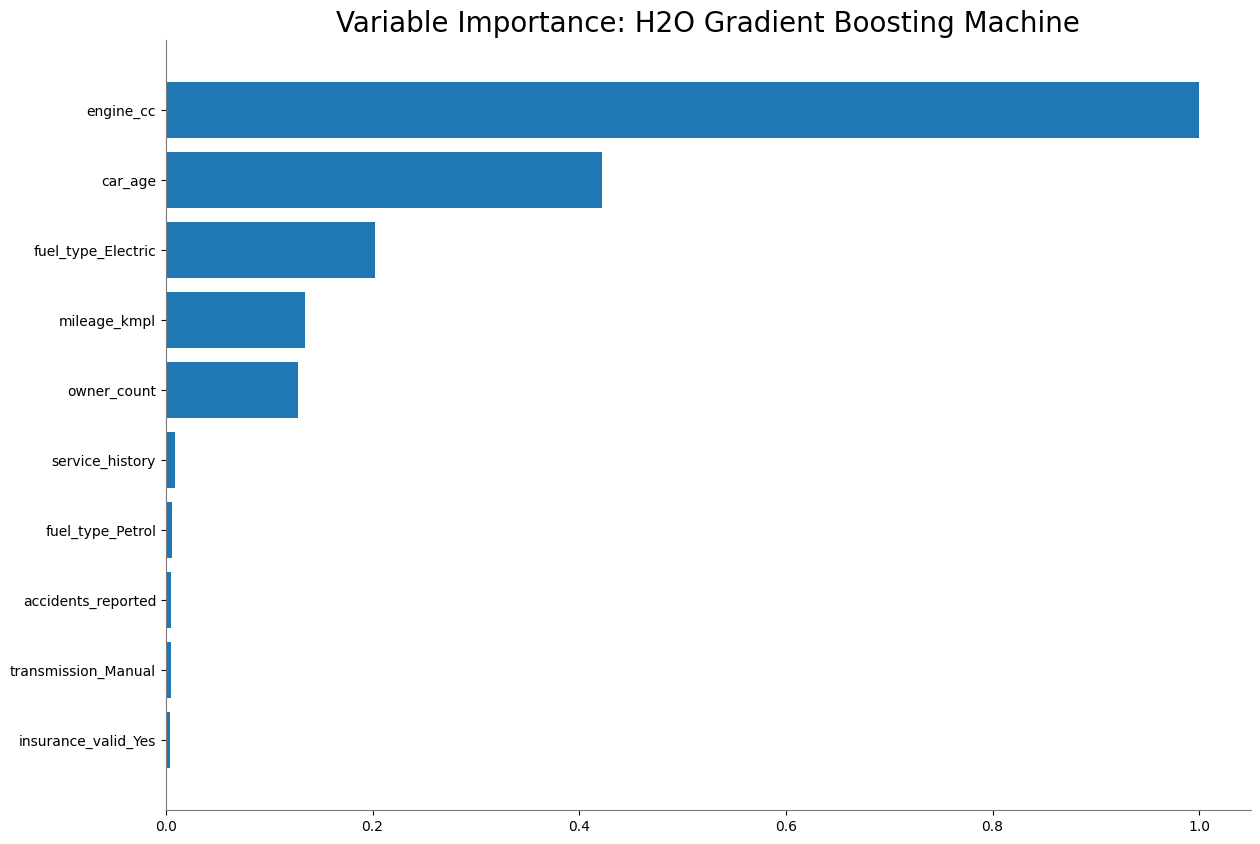


Top 5 features for model : XGBoost_3_AutoML_1_20250704_115148:


<Figure size 640x480 with 0 Axes>

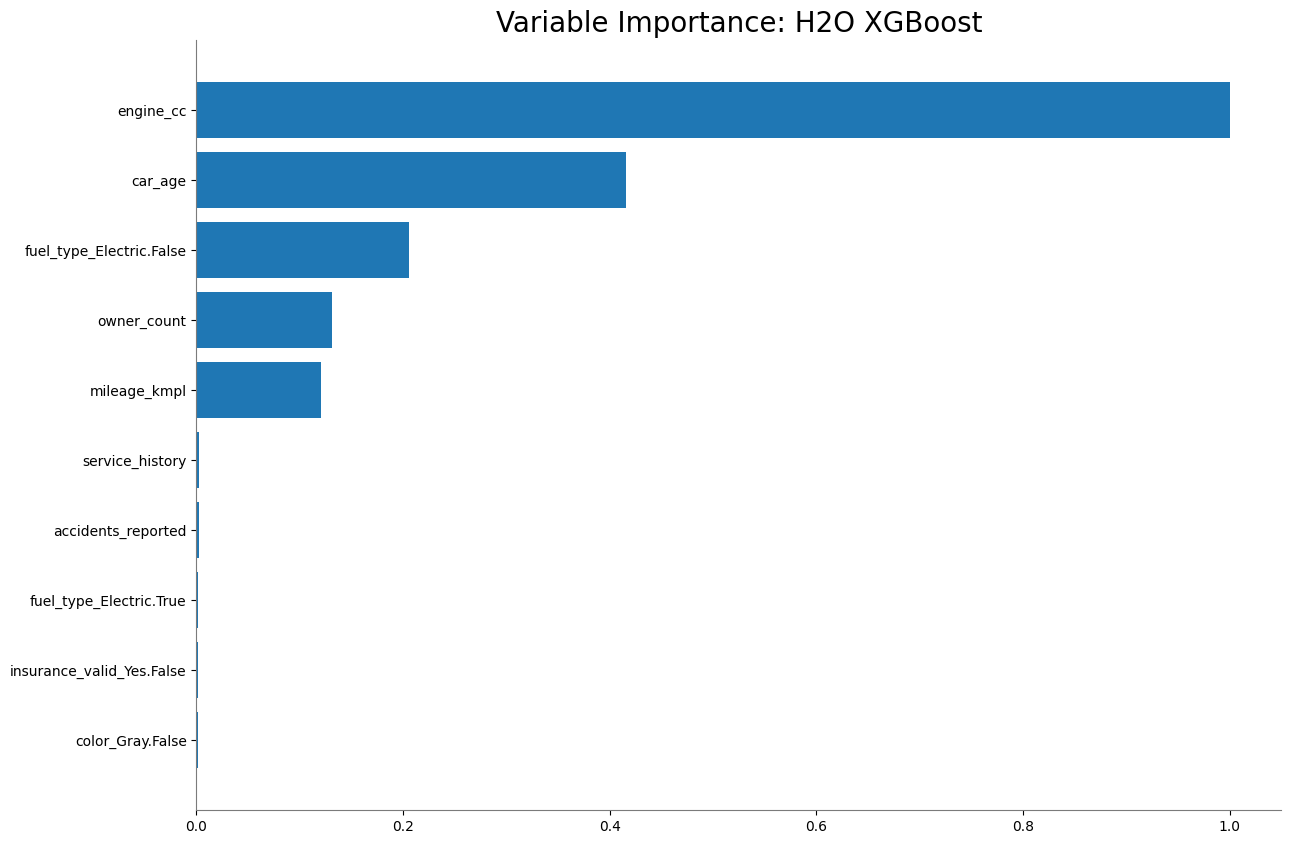


Top 5 features for model : GBM_4_AutoML_1_20250704_115148:


<Figure size 640x480 with 0 Axes>

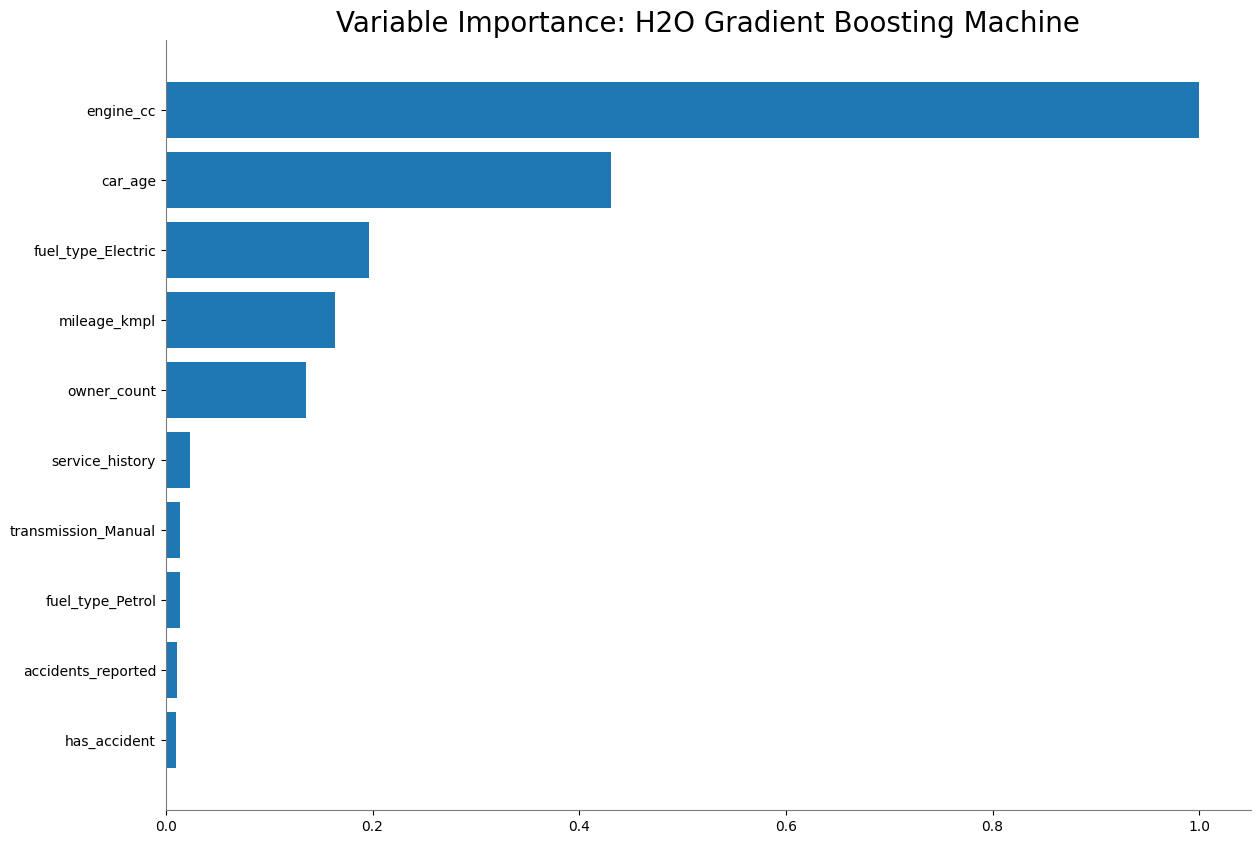

<Figure size 640x480 with 0 Axes>

In [58]:
# Getting top 5 most important features for non stacked ensemble models

lb = automl.leaderboard.as_data_frame()

# Filter out Stacked Ensembles if you only want base models
top_models = lb[~lb['model_id'].str.contains("StackedEnsemble")].head(5)

for model_id in top_models['model_id']:
    model = h2o.get_model(model_id)

    # Check if model supports variable importance
    if hasattr(model, 'varimp'):
      print(f"\nTop 5 features for model : {model_id}:")
      varimp = model.varimp_plot()
      #print(varimp[["variable", "relative_importance"]].head(5))
    else:
      print(f"\nModel {model_id} does not support variable importance.")


In [60]:
# Log the feature importances to CometML

for model_id in top_models['model_id']:
    model = h2o.get_model(model_id)

    # Check if model supports variable importance
    if hasattr(model, 'varimp'):
      varimp = model.varimp(use_pandas=True).head(5)
      exp.log_table(f"{model_id}_top5_features.csv",tabular_data=varimp,)